# Notebook 2: Cross-Repository Evaluation Overview

**Goal:** Describe the study population and overall evaluation scope before ranking any approach.

**Inputs:** `evaluation_attempts.csv`, `evaluation_overview.json`

**RQs addressed:** RQ1 (scope), RQ2 (scope)

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data')
required = DATA_DIR / 'evaluation_attempts.csv'
if not required.exists():
    raise FileNotFoundError(f'Missing required analysis CSV: {required}')
attempts  = pd.read_csv(required)

overview_path = DATA_DIR / 'evaluation_overview.json'
overview = json.loads(overview_path.read_text()) if overview_path.exists() else {}

## 1. What Was Evaluated?

Study population: number of repositories, candidates (unique source methods), total attempts, and which models and tools participated. This establishes the scope before any outcome reporting.


In [2]:
scope = overview.get('scope', {})
scope_df = pd.DataFrame(list(scope.items()), columns=['metric', 'value'])
display(scope_df)

# Headline cards
for k, v in scope.items():
    print(f'  {k}: {v}')

,metric,value
0,repositories_evaluated,2
1,candidates_evaluated,2
2,total_attempts,10
3,llm_attempts,6
4,agentic_attempts,4
5,models_evaluated,3
6,tools_evaluated,2


  repositories_evaluated: 2
  candidates_evaluated: 2
  total_attempts: 10
  llm_attempts: 6
  agentic_attempts: 4
  models_evaluated: 3
  tools_evaluated: 2


## 2. How Much Was Generated?

Total generated tests by lane. Agentic attempts may produce multiple tests per invocation; LLM attempts always produce one. Use this alongside attempt counts to compute tests-per-attempt.


Generated test counts:
  generated_tests_total: 22
  generated_tests_llm: 6
  generated_tests_agentic: 16
  candidates_with_at_least_one_test: 2
  candidates_with_multiple_tests: 2


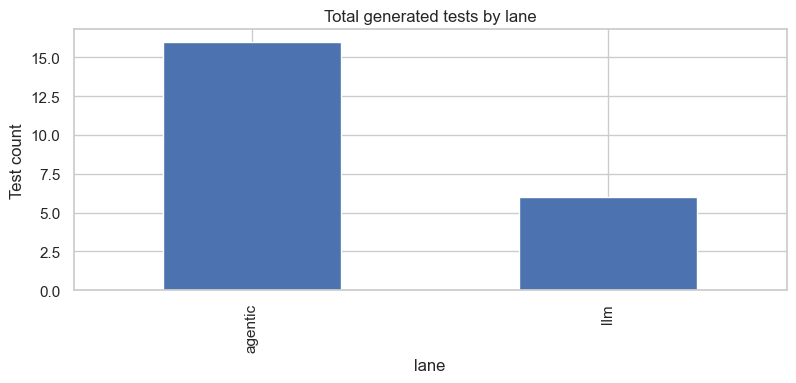

In [3]:
gen = overview.get('generated_tests', {})
print('Generated test counts:')
for k, v in gen.items():
    print(f'  {k}: {v}')

if 'generated_test_count' in attempts.columns and 'lane' in attempts.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    attempts.groupby('lane')['generated_test_count'].sum().plot(kind='bar', ax=ax)
    ax.set_title('Total generated tests by lane')
    ax.set_ylabel('Test count')
    plt.tight_layout()
    plt.show()

## 3. What Happened Overall?

Headline outcome counts across all repositories. `validated_successes` is the broad count (VEP + VLI). `validated_evidence_positive_attempts` is the narrower count where tests passed **and** metrics improved ≥ noise floor — this is the primary practical-impact measure. Report both figures to avoid overstating impact.


In [4]:
outcomes = overview.get('outcomes', {})
print('Outcome counts:')
for k, v in outcomes.items():
    print(f'  {k}: {v}')

if 'lane' in attempts.columns and 'validated_success' in attempts.columns:
    summary = attempts.groupby('lane')['validated_success'].agg(['sum', 'count', 'mean'])
    summary.columns = ['successes', 'total', 'rate']
    display(summary)

Outcome counts:
  validated_successes: 4
  positive_impact_attempts: 9
  validated_evidence_positive_attempts: 4
  validated_low_impact_attempts: 0
  outcome_validatedevidencepositive_total: 4
  outcome_validatedevidencepositive_llm: 1
  outcome_validatedevidencepositive_agentic: 3
  outcome_validatedlowimpact_total: 0
  outcome_validatedlowimpact_llm: 0
  outcome_validatedlowimpact_agentic: 0
  outcome_failedevidencepositive_total: 4
  outcome_failedevidencepositive_llm: 4
  outcome_failedevidencepositive_agentic: 0
  outcome_validationfailed_total: 2
  outcome_validationfailed_llm: 1
  outcome_validationfailed_agentic: 1
  outcome_nochange_total: 0
  outcome_nochange_llm: 0
  outcome_nochange_agentic: 0
  outcome_skipped_total: 0
  outcome_skipped_llm: 0
  outcome_skipped_agentic: 0
  outcome_timedout_total: 0
  outcome_timedout_llm: 0
  outcome_timedout_agentic: 0
  outcome_toolfailed_total: 0
  outcome_toolfailed_llm: 0
  outcome_toolfailed_agentic: 0
  outcome_buildfailed_total: 0

,successes,total,rate
lane,,,
agentic,3,4,0.750000
llm,1,6,0.166667


## 4. How Much Did Metrics Move?

Distribution of coverage and mutation deltas across all attempts. **Note:** failed attempts that produced no output are excluded from this distribution (missing delta = NA). The visible distribution is conditional on the attempt producing a measurement, so it overestimates typical movement. Red dashed line at 0 marks the no-change boundary.


Metric movement:
  coverage_improvements: 9
  mutation_improvements: 3
  metric_improvements: 9
  mean_coverage_delta: 0.2384057971014492
  mean_mutation_delta: 2.0477618999254252


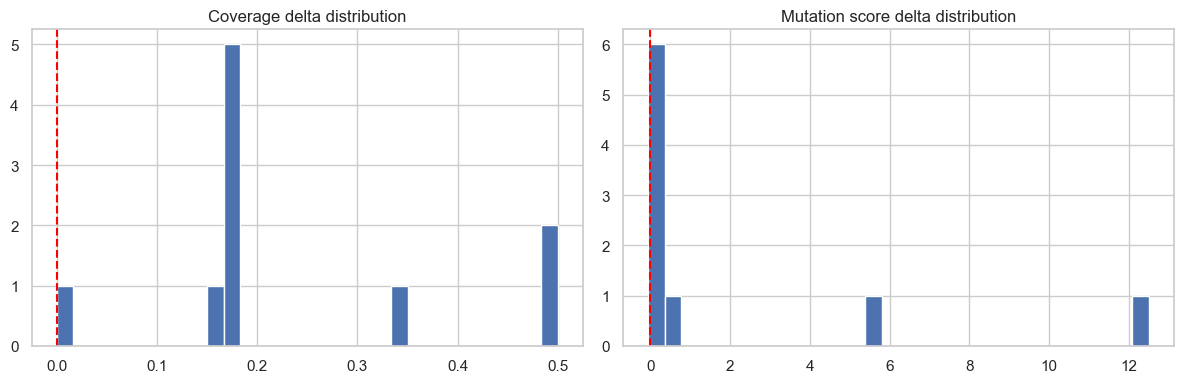

In [5]:
movement = overview.get('metric_movement', {})
print('Metric movement:')
for k, v in movement.items():
    print(f'  {k}: {v}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if 'coverage_delta' in attempts.columns:
    attempts['coverage_delta'].dropna().hist(bins=30, ax=axes[0])
    axes[0].axvline(0, color='red', linestyle='--')
    axes[0].set_title('Coverage delta distribution')
if 'mutation_score_delta' in attempts.columns:
    attempts['mutation_score_delta'].dropna().hist(bins=30, ax=axes[1])
    axes[1].axvline(0, color='red', linestyle='--')
    axes[1].set_title('Mutation score delta distribution')
plt.tight_layout()
plt.show()

## 5. What Did It Cost?

Total and median wall-clock runtime and token usage across the full evaluation. Provides the resource denominator for interpreting success rates in later notebooks.


In [6]:
cost = overview.get('cost', {})
print('Cost / runtime:')
for k, v in cost.items():
    print(f'  {k}: {v}')

if 'duration_seconds' in attempts.columns and 'lane' in attempts.columns:
    display(attempts.groupby('lane')['duration_seconds'].agg(['median', 'sum', 'count']))

Cost / runtime:
  total_duration_seconds: 4372.9300444
  median_duration_seconds: 217.67045645000002
  total_tokens: 698180


,median,sum,count
lane,,,
agentic,513.358822,2003.247521,4
llm,212.993013,2369.682523,6


## 6. How Complete Is the Data?

Missing-data heatmap: percentage of NA values per key outcome column per lane. Systematic missingness in coverage/mutation columns indicates the validation pipeline did not complete for those attempts, which affects the metric-movement distributions above.


Missingness:
  missing_coverage_before: 0
  missing_coverage_after: 0
  missing_mutation_before: 0
  missing_mutation_after: 1
  missing_tokens: 0
  missing_outcome_classification: 0
  missing_tool_attempt_id: 10


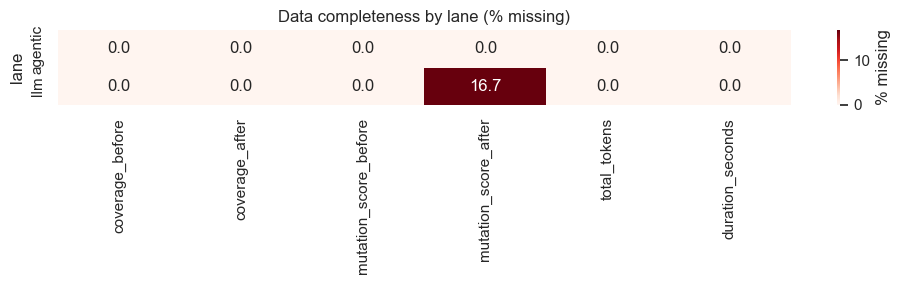

In [7]:
completeness = overview.get('data_completeness', {})
print('Missingness:')
for k, v in completeness.items():
    print(f'  {k}: {v}')

# Heatmap of null % by lane × column
key_cols = ['coverage_before', 'coverage_after', 'mutation_score_before',
            'mutation_score_after', 'total_tokens', 'duration_seconds']
present = [c for c in key_cols if c in attempts.columns]
if present and 'lane' in attempts.columns:
    null_pct = attempts.groupby('lane')[present].apply(lambda g: g.isna().mean() * 100)
    fig, ax = plt.subplots(figsize=(10, 3))
    sns.heatmap(null_pct, annot=True, fmt='.1f', cmap='Reds', ax=ax, cbar_kws={'label': '% missing'})
    ax.set_title('Data completeness by lane (% missing)')
    plt.tight_layout()
    plt.show()

## 7. Outcome Classification by Lane

Full outcome taxonomy (ValidatedEvidencePositive, ValidatedLowImpact, FailedEvidencePositive, BuildFailed, TestsFailed, etc.) broken down by lane. More diagnostic than the binary success rate: shows where each lane's attempts most often fail.


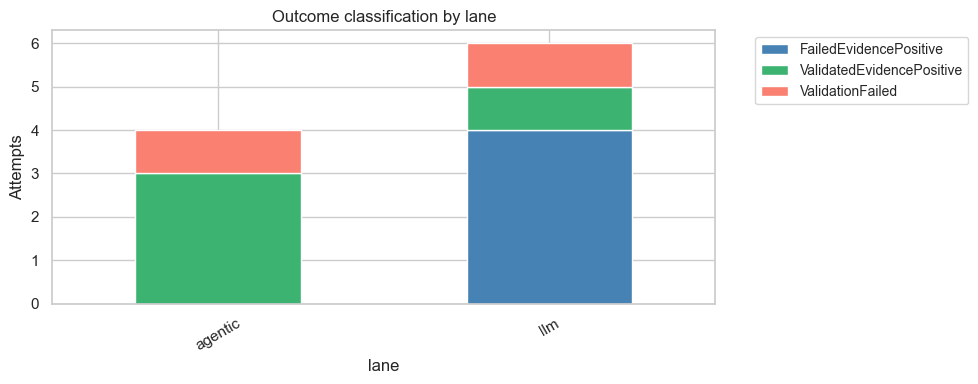


Outcome distribution (%):


outcome_classification,FailedEvidencePositive,ValidatedEvidencePositive,ValidationFailed
lane,,,
agentic,0.0,75.0,25.0
llm,66.7,16.7,16.7


In [8]:
from analysis.plots import outcome_classification_bar

if 'outcome_classification' in attempts.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    outcome_classification_bar(attempts, group_col='lane', ax=ax)
    plt.tight_layout()
    plt.show()

    oc_table = attempts.groupby(['lane', 'outcome_classification']).size().unstack(fill_value=0)
    oc_pct = oc_table.div(oc_table.sum(axis=1), axis=0).mul(100)
    print('\nOutcome distribution (%):')
    display(oc_pct.round(1))
else:
    print('outcome_classification column not found.')

## 8. Source Method Complexity Profile

Distribution and per-repository median of structural metrics for the evaluated source methods. Characterises the difficulty profile of the study population — a set dominated by simple methods limits claims about real-world generalisability.


,count,mean,std,min,25%,50%,75%,max
source_method_cc,10.0,7.10,1.45,5.0,5.75,8.00,8.00,8.00
source_method_mi,10.0,64.90,1.45,64.0,64.00,64.00,66.25,67.00
source_method_coupling,10.0,3.60,0.97,3.0,3.00,3.00,4.50,5.00
source_method_dit,10.0,0.00,0.00,0.0,0.00,0.00,0.00,0.00
source_method_sloc,10.0,30.90,8.21,19.0,23.25,36.00,36.00,36.00
source_method_baseline_coverage,10.0,0.61,0.07,0.5,0.54,0.65,0.65,0.65


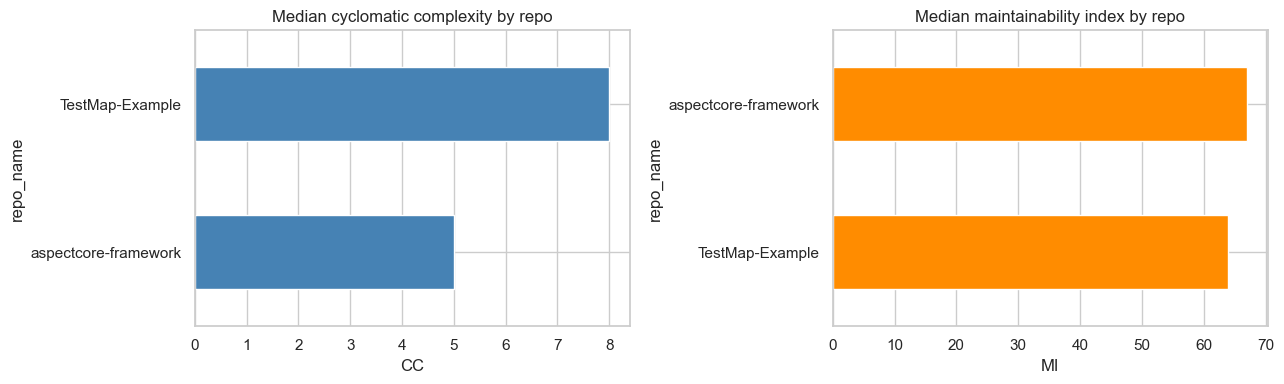

In [9]:
source_cols = [c for c in [
    'source_method_cc', 'source_method_mi', 'source_method_coupling',
    'source_method_dit', 'source_method_sloc', 'source_method_baseline_coverage',
] if c in attempts.columns]

if source_cols:
    display(attempts[source_cols].describe().T.round(2))

    # Per-repo median complexity
    if 'repo_name' in attempts.columns and 'source_method_cc' in attempts.columns:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        attempts.groupby('repo_name')['source_method_cc'].median().sort_values().plot(
            kind='barh', ax=axes[0], color='steelblue')
        axes[0].set_title('Median cyclomatic complexity by repo')
        axes[0].set_xlabel('CC')
        attempts.groupby('repo_name')['source_method_mi'].median().sort_values().plot(
            kind='barh', ax=axes[1], color='darkorange')
        axes[1].set_title('Median maintainability index by repo')
        axes[1].set_xlabel('MI')
        plt.tight_layout()
        plt.show()
else:
    print('Source method metric columns not found.')

## 9. Test Smell Overview

Aggregate count of test smell instances in baseline vs generated tests across all repositories. A higher generated smell rate signals systematic quality degradation in the tool outputs.


Baseline: total=0, attempts with smells=0 (0.0%)
Generated: total=13, attempts with smells=7 (70.0%)


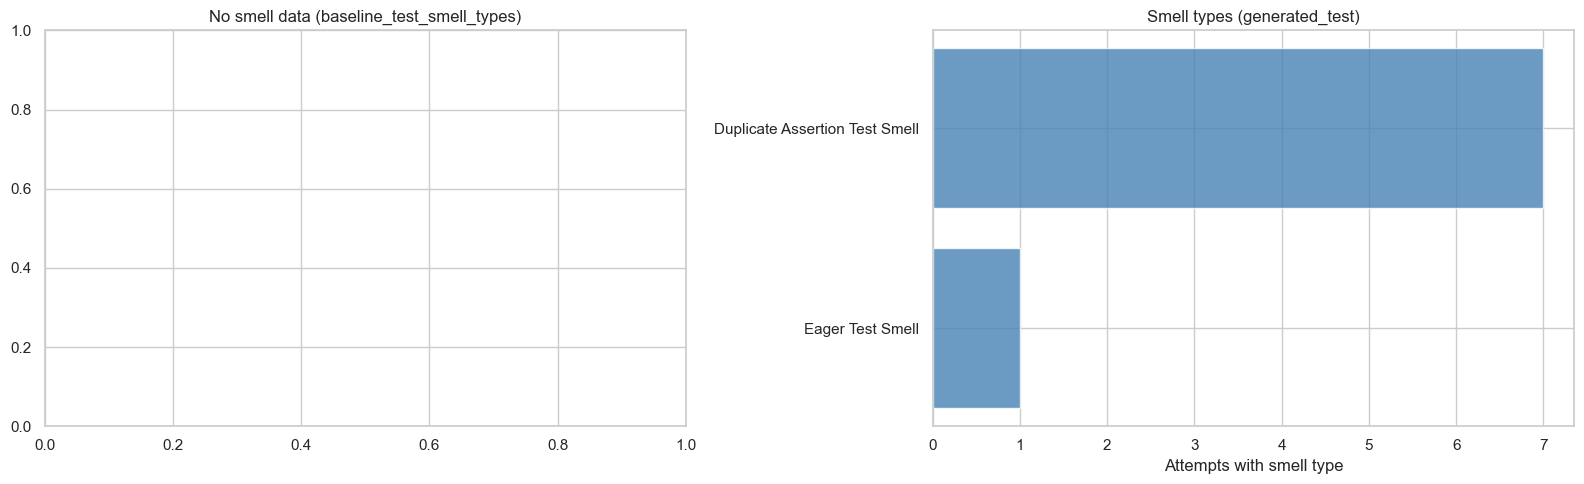

In [10]:
from analysis.plots import smell_type_breakdown

for count_col, types_col, label in [
    ('baseline_test_smell_count',  'baseline_test_smell_types',  'Baseline'),
    ('generated_test_smell_count', 'generated_test_smell_types', 'Generated'),
]:
    if count_col in attempts.columns:
        total = attempts[count_col].fillna(0).sum()
        with_smells = (attempts[count_col].fillna(0) > 0).sum()
        pct = with_smells / len(attempts) * 100
        print(f'{label}: total={int(total)}, attempts with smells={with_smells} ({pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
smell_type_breakdown(attempts, 'baseline_test_smell_types',  ax=axes[0])
smell_type_breakdown(attempts, 'generated_test_smell_types', ax=axes[1])
plt.tight_layout()
plt.show()

## 10. Timing and Token Usage

Median and total runtime broken down by phase (generation vs validation) and by lane. Token usage by lane. Provides the cost context for the cross-repository lane comparison in Notebook 3.


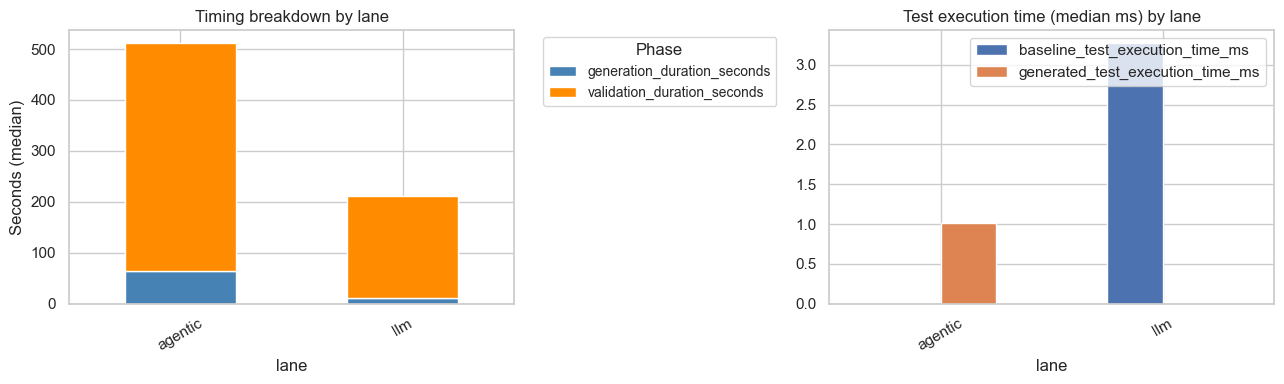


Token usage by lane:


total_tokens           cumulative_tokens         
                 sum    median               sum   median
lane                                                     
agentic       630465  153959.0                 0      0.0
llm            67715    1818.5            224148  39090.0

In [11]:
from analysis.plots import timing_stacked_bar

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
timing_stacked_bar(attempts, group_col='lane', ax=axes[0])

exec_cols = [c for c in ['baseline_test_execution_time_ms', 'generated_test_execution_time_ms']
             if c in attempts.columns]
if exec_cols:
    attempts.groupby('lane')[exec_cols].median().plot(kind='bar', ax=axes[1])
    axes[1].set_title('Test execution time (median ms) by lane')
    axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

token_cols = [c for c in ['total_tokens', 'cumulative_tokens'] if c in attempts.columns]
if token_cols:
    print('\nToken usage by lane:')
    display(attempts.groupby('lane')[token_cols].agg(['sum', 'median']))